# EDA and data cleaning

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Get the directory of the current notebook
notebook_dir = os.path.abspath('')

# 2. Go up two levels to reach the 'src' root directory
src_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

# 3. Target the 'utils' folder exactly
utils_path = os.path.join(src_root, 'utils')

# 4. Append to sys.path if it's not already there
if utils_path not in sys.path:
    sys.path.append(utils_path)

#  FORCE CACHE CLEAR: Manually evict the old module version from Python's memory
if 'eda_and_data_cleaning' in sys.modules:
    del sys.modules['eda_and_data_cleaning']

print(f"Added to path: {utils_path}")

# 5. Import your functions seamlessly
from eda_and_data_cleaning import (
    summarize_dataset_structure, 
    drop_missing_landmark_frames, 
    plot_feature_variance_by_class, 
    plot_feature_collinearity_matrix, 
    plot_signal_stability_over_time
)

Added to path: d:\YogAi_Models_Refactor\src\utils


In [2]:

# mountain_pose_csv = "../../../data/processed/engineered_features/mountain_pose/mountain_pose_features.csv"

raw_mountain_df = summarize_dataset_structure("../../../data/processed/engineered_features/mountain_pose/mountain_pose_features.csv")


       RESEARCH COMPREHENSIVE PROFILE: ../../../data/processed/engineered_features/mountain_pose/mountain_pose_features.csv               
 DATASET DIMENSIONS:
   - Total Recorded Frames (Rows): 4640
   - Total Columns: 11
   - Biomechanical Features Detected (8): ['left_torso_hip_angle', 'right_torso_hip_angle', 'left_shoulder_arm_angle', 'right_shoulder_arm_angle', 'neck_tilt_angle', 'feet_distance_normalized', 'ear_shoulder_lateral_delta', 'plumb_line_alignment']

 FEATURE DESCRIPTIVE STATISTICS (ANGLES/DISTANCES):


,mean,std,min,max
left_torso_hip_angle,152.777575,13.297562,75.989367,176.682299
right_torso_hip_angle,148.748922,14.631162,54.148518,176.535484
left_shoulder_arm_angle,54.989100,16.618361,3.126442,162.191084
right_shoulder_arm_angle,51.380780,15.376053,3.143748,155.769398
neck_tilt_angle,153.383317,8.583727,93.151742,166.707720
feet_distance_normalized,0.808326,0.455478,0.075071,2.991637
ear_shoulder_lateral_delta,6.217492,11.858859,0.000364,178.784503
plumb_line_alignment,0.501101,0.142015,0.121772,1.092925




 LABEL/CLASS DISTRIBUTION (Target Balance):
   - Class 'correct': 1040 frames (22.41%)
   - Class 'arms_not_dropped': 900 frames (19.40%)
   - Class 'bent_forward': 900 frames (19.40%)
   - Class 'tilted_head': 900 frames (19.40%)
   - Class 'wide_stance': 900 frames (19.40%)


📹 VIDEO SOURCE DISTRIBUTION (Data Diversity):
   - Total unique video sources: 45
   - Frames per top sources:
source_id
arms_not_dropped_1.mp4    225
arms_not_dropped_2.mp4    225
arms_not_dropped_3.mp4    225
arms_not_dropped_4.mp4    225
bent_forward_1.mp4        225

🔍 LANDMARK DROP/MISSING VALUE PROFILE:
   - Phenomenal! Zero missing values detected in the raw dataset.



In [3]:

# Run Targeted Structural Cleaning
cleaned_mountain_df = drop_missing_landmark_frames(raw_mountain_df)


[CLEANING] Dropped 0 frames due to incomplete landmark tracking.
[CLEANING] Remaining stable frames: 4640


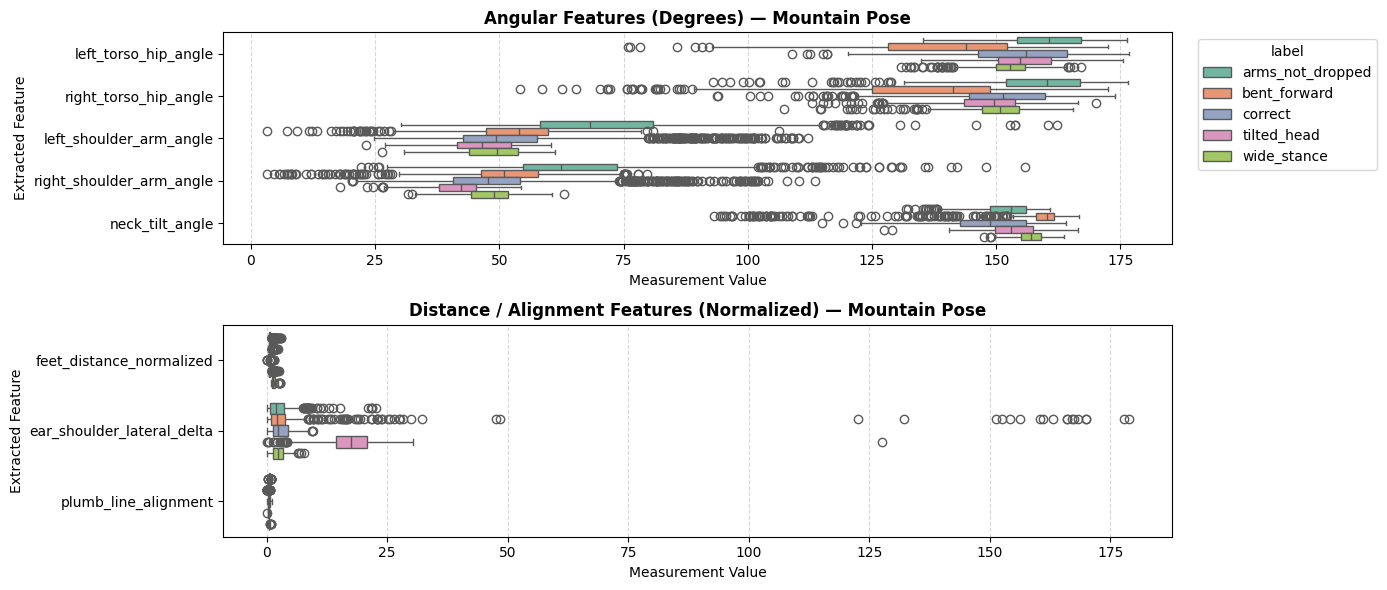

In [4]:

# Visualization
plot_feature_variance_by_class(cleaned_mountain_df, pose_name="Mountain Pose")


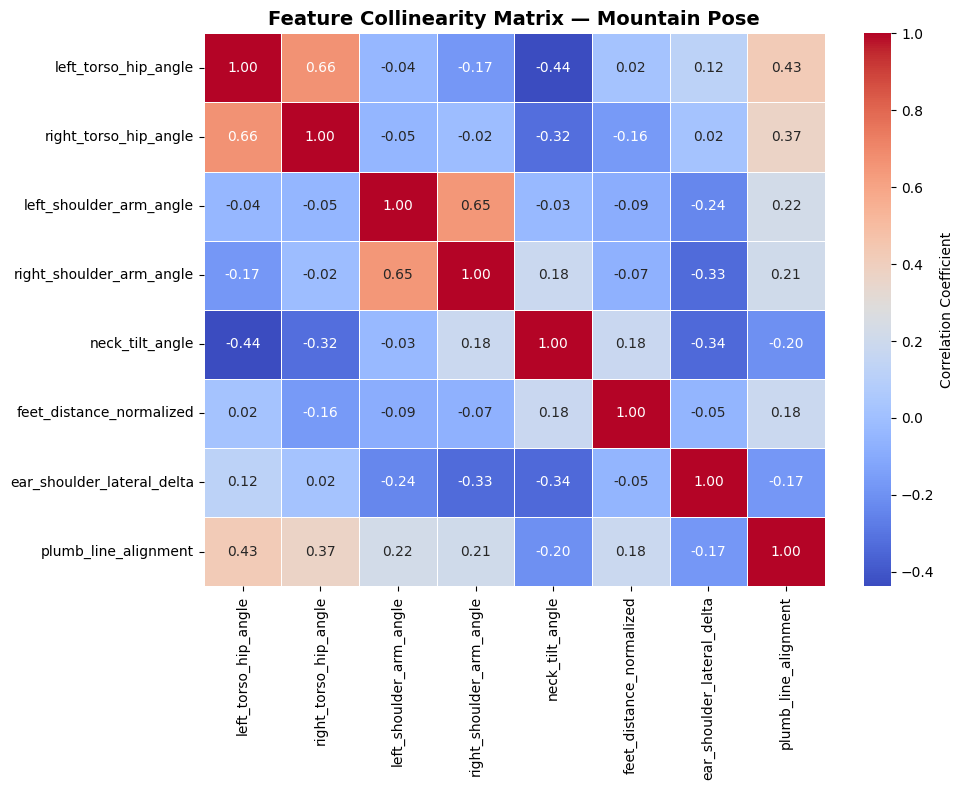

In [5]:
plot_feature_collinearity_matrix(cleaned_mountain_df, pose_name="Mountain Pose")

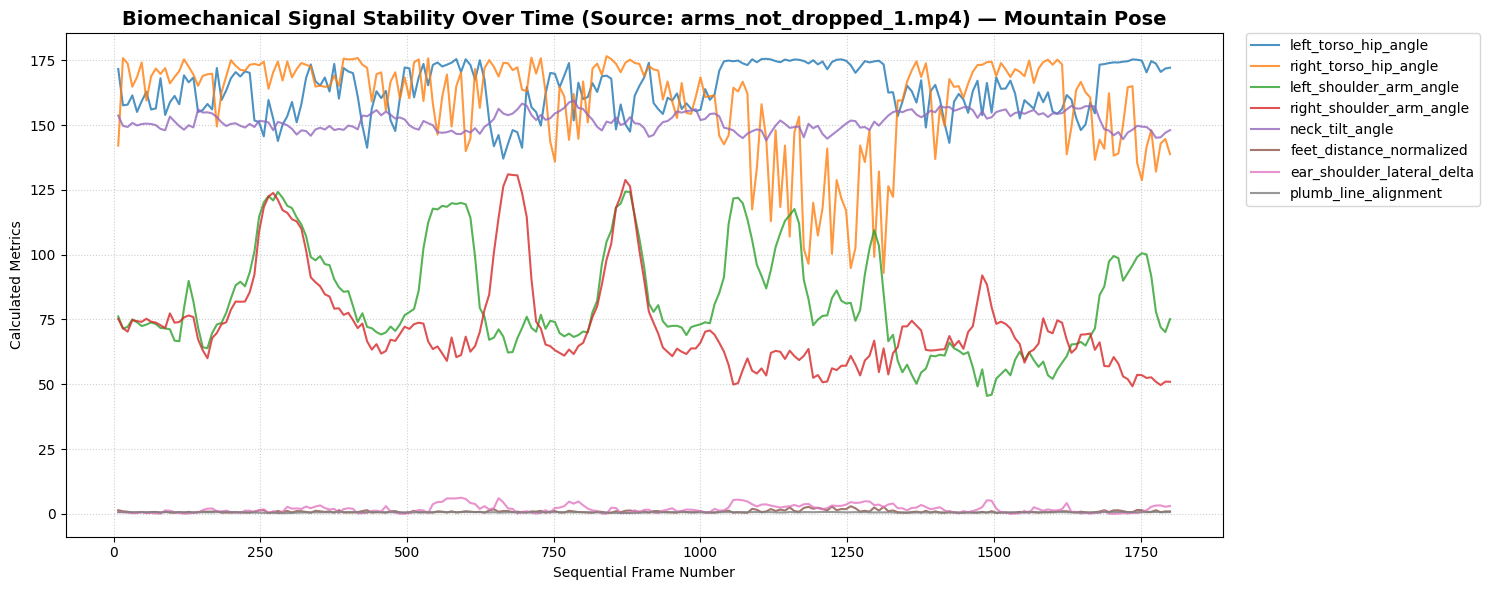

In [6]:
plot_signal_stability_over_time(cleaned_mountain_df, pose_name="Mountain Pose")
